In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import torch

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
test_path = data_path + '/test'
models_path = project_path + '/models'
results_path = project_path + '/results'

channel = "A-8"

test_data = np.load(
    test_path + "/" + channel + ".npy"
)

test_telemetry = test_data[:, 0]

model_path = models_path + '/lstm_autoencoder_A8.pt'

print("Project path:", project_path)
print("Channel:", channel)
print("Test telemetry shape:", test_telemetry.shape)
print("Model exists:", os.path.exists(model_path))
print("Results folder exists:", os.path.exists(results_path))

Mounted at /content/drive
Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Channel: A-8
Test telemetry shape: (8375,)
Model exists: True
Results folder exists: True


##Recreate the LSTM Autoencoder

We need to recreate the same architecture that we used in SERIAL 23/24 before loading the saved model.

In [2]:
class LSTMAutoencoder(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=32, latent_size=16):
        super().__init__()

        self.encoder = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = torch.nn.Linear(
            hidden_size,
            latent_size
        )

        self.decoder_fc = torch.nn.Linear(
            latent_size,
            hidden_size
        )

        self.decoder = torch.nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = torch.nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(hidden[-1])

        decoder_input = self.decoder_fc(latent)
        decoder_input = decoder_input.unsqueeze(1)

        decoder_input = decoder_input.repeat(
            1,
            x.size(1),
            1
        )

        decoded_sequence, _ = self.decoder(decoder_input)

        output = self.output_layer(decoded_sequence)

        return output


model = LSTMAutoencoder()

model.load_state_dict(
    torch.load(
        model_path,
        map_location='cpu'
    )
)

model.eval()

print("LSTM Autoencoder loaded successfully.")
print("Total parameters:", sum(p.numel() for p in model.parameters()))

LSTM Autoencoder loaded successfully.
Total parameters: 14033


#Create the real-time sliding window

In a real spacecraft system, telemetry arrives one value at a time. The model needs the latest 50 values to make a decision.

In [3]:
window_size = 50

def create_realtime_window(telemetry_buffer, window_size=50):
    if len(telemetry_buffer) < window_size:
        return None

    window = np.array(
        telemetry_buffer[-window_size:],
        dtype=np.float32
    )

    window = torch.tensor(
        window
    ).unsqueeze(0).unsqueeze(-1)

    return window


print("Window size:", window_size)
print("Function created successfully.")

Window size: 50
Function created successfully.


##Calculate anomaly score

Now we connect the 50-value window → LSTM → reconstruction error.

In [4]:
def calculate_anomaly_score(window, model):
    with torch.no_grad():
        reconstructed = model(window)

        error = torch.mean(
            (window - reconstructed) ** 2
        )

    return error.item()


print("Anomaly score function created successfully.")

Anomaly score function created successfully.


##Test one real-time window

Before building the full pipeline, let's make sure one window actually produces a valid anomaly score.

In [5]:
telemetry_buffer = test_telemetry[:window_size].tolist()

window = create_realtime_window(
    telemetry_buffer,
    window_size
)

anomaly_score = calculate_anomaly_score(
    window,
    model
)

print("Window shape:", window.shape)
print("Anomaly score:", anomaly_score)

Window shape: torch.Size([1, 50, 1])
Anomaly score: 0.009550475515425205


###Find the actual A-8 training file

In [5]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

search_root = project_path + '/data/raw/archive'

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file == 'A-8.npy':
            print("Found:", os.path.join(root, file))

##Inspect the dataset folders


In [6]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

raw_path = project_path + '/data/raw'

for root, dirs, files in os.walk(raw_path):
    level = root.replace(raw_path, '').count(os.sep)

    if level <= 4:
        indent = '  ' * level
        print(indent + os.path.basename(root) + '/')

        for file in files[:10]:
            print(indent + '  ' + file)

In [7]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

print("Project exists:", os.path.exists(project_path))

if os.path.exists(project_path):
    print("\nProject contents:")

    for item in os.listdir(project_path):
        print("-", item)
else:
    print("Project folder not found.")

Project exists: False
Project folder not found.


##Mount Google Drive

In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


###Find the project folder

In [10]:
import os

mydrive_path = '/content/drive/MyDrive'

print("MyDrive contents:")

for item in os.listdir(mydrive_path):
    print("-", item)

MyDrive contents:
- Untitled spreadsheet.gsheet
- 2025 Fall class time .gsheet
- how did you solve the 15 eqation can you give me....gsheet
- give me the answer of this pfd . and see the maks....gsheet
- here i write a project proposal for me, now you h....gdoc
- do i need to write c equivalent code , this is wh....gdoc
- Untitled document (1).gdoc
- Untitled document.gdoc
- Spacecraft-Anomaly-Detection
- Arsenic_skin_Detection


#####Check project structure

In [11]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

print("Project exists:", os.path.exists(project_path))
print("\nProject folders:")

for item in os.listdir(project_path):
    print("-", item)

Project exists: True

Project folders:
- notebooks
- data
- results
- figures
- models
- documents
- project_test.txt
- .git
- .gitignore


####Verify the dataset

In [12]:
import os

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
data_root = project_path + '/data/raw'

print("Data root exists:", os.path.exists(data_root))

for root, dirs, files in os.walk(data_root):
    level = root.replace(data_root, '').count(os.sep)

    if level <= 4:
        indent = '  ' * level
        print(indent + os.path.basename(root) + '/')

        for file in files[:5]:
            print(indent + '  ' + file)

Data root exists: True
raw/
  archive/
    labeled_anomalies.csv
    data/
      data/
        2018-05-19_15.00.10/
          params.log
        test/
          E-1.npy
          A-4.npy
          D-6.npy
          A-2.npy
          D-7.npy
        train/
          E-13.npy
          B-1.npy
          T-9.npy
          D-7.npy
          E-11.npy


#Now Calculate the detection threshold

In [15]:
import os
import numpy as np
import torch

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

train_path = project_path + '/data/raw/archive/data/data/train'
models_path = project_path + '/models'

channel = "A-8"
window_size = 50

model_path = models_path + '/lstm_autoencoder_A8.pt'


class LSTMAutoencoder(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=32, latent_size=16):
        super().__init__()

        self.encoder = torch.nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = torch.nn.Linear(
            hidden_size,
            latent_size
        )

        self.decoder_fc = torch.nn.Linear(
            latent_size,
            hidden_size
        )

        self.decoder = torch.nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = torch.nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(hidden[-1])

        decoder_input = self.decoder_fc(latent)
        decoder_input = decoder_input.unsqueeze(1)
        decoder_input = decoder_input.repeat(
            1,
            x.size(1),
            1
        )

        decoded_sequence, _ = self.decoder(decoder_input)

        output = self.output_layer(decoded_sequence)

        return output


def create_windows(telemetry, window_size=50):
    windows = []

    for i in range(len(telemetry) - window_size + 1):
        windows.append(
            telemetry[i:i + window_size]
        )

    return np.array(windows)


train_data = np.load(
    train_path + "/" + channel + ".npy"
)

train_telemetry = train_data[:, 0]

train_windows = create_windows(
    train_telemetry,
    window_size
)

X_train = torch.tensor(
    train_windows,
    dtype=torch.float32
).unsqueeze(-1)


model = LSTMAutoencoder()

model.load_state_dict(
    torch.load(
        model_path,
        map_location='cpu'
    )
)

model.eval()


with torch.no_grad():
    train_reconstructed = model(X_train)

train_errors = torch.mean(
    (X_train - train_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

threshold = np.percentile(
    train_errors,
    99
)

print("Training windows:", X_train.shape)
print("Training reconstruction errors:", train_errors.shape)
print("Detection threshold:", threshold)
print("Model parameters:", sum(p.numel() for p in model.parameters()))

Training windows: torch.Size([713, 50, 1])
Training reconstruction errors: (713,)
Detection threshold: 0.11613636
Model parameters: 14033


##Make the anomaly decision

Now we'll combine:

anomaly score + threshold → decision

In [17]:
test_path = project_path + '/data/raw/archive/data/data/test'

test_data = np.load(
    test_path + "/" + channel + ".npy"
)

test_telemetry = test_data[:, 0]

telemetry_buffer = test_telemetry[:window_size].tolist()

window = create_windows(
    np.array(telemetry_buffer),
    window_size
)

X_window = torch.tensor(
    window,
    dtype=torch.float32
).unsqueeze(-1)

with torch.no_grad():
    reconstructed = model(X_window)

anomaly_score = torch.mean(
    (X_window - reconstructed) ** 2
).item()


def classify_anomaly(anomaly_score, threshold):
    if anomaly_score > threshold:
        return "ANOMALY"
    else:
        return "NORMAL"


decision = classify_anomaly(
    anomaly_score,
    threshold
)

print("Window shape:", X_window.shape)
print("Anomaly score:", anomaly_score)
print("Threshold:", threshold)
print("Decision:", decision)

Window shape: torch.Size([1, 50, 1])
Anomaly score: 0.009550475515425205
Threshold: 0.11613636
Decision: NORMAL


##Simulate real-time telemetrySimulate real-time telemetry

receiving telemetry one value at a time and continuously checking the latest 50 values.

In [19]:
import pandas as pd

telemetry_buffer = []

detections = []

for value in test_telemetry[:200]:

    telemetry_buffer.append(value)

    if len(telemetry_buffer) < window_size:
        continue

    window = np.array(
        telemetry_buffer[-window_size:],
        dtype=np.float32
    )

    X_window = torch.tensor(
        window
    ).unsqueeze(0).unsqueeze(-1)

    with torch.no_grad():
        reconstructed = model(X_window)

    anomaly_score = torch.mean(
        (X_window - reconstructed) ** 2
    ).item()

    decision = classify_anomaly(
        anomaly_score,
        threshold
    )

    detections.append({
        "telemetry_index": len(telemetry_buffer) - 1,
        "anomaly_score": anomaly_score,
        "decision": decision
    })

detections_df = pd.DataFrame(detections)

print("Telemetry values processed:", 200)
print("Windows evaluated:", len(detections_df))
print("\nFirst 5 detections:")
print(detections_df.head())

Telemetry values processed: 200
Windows evaluated: 151

First 5 detections:
   telemetry_index  anomaly_score decision
0               49       0.009550   NORMAL
1               50       0.010167   NORMAL
2               51       0.010782   NORMAL
3               52       0.011398   NORMAL
4               53       0.012014   NORMAL


##Count detected anomalies

Now let's see how many anomalies the real-time simulation detected in those first 200 telemetry values.

In [20]:
anomaly_count = (
    detections_df["decision"] == "ANOMALY"
).sum()

normal_count = (
    detections_df["decision"] == "NORMAL"
).sum()

print("Total windows evaluated:", len(detections_df))
print("Normal windows:", normal_count)
print("Anomalous windows:", anomaly_count)

Total windows evaluated: 151
Normal windows: 81
Anomalous windows: 70


##See where the detector starts flagging anomalies

Now let's inspect the first few anomaly detections.

In [21]:
anomaly_detections = detections_df[
    detections_df["decision"] == "ANOMALY"
]

print("Number of anomaly detections:", len(anomaly_detections))

print("\nFirst 10 anomaly detections:")
print(
    anomaly_detections.head(10)
)

Number of anomaly detections: 70

First 10 anomaly detections:
    telemetry_index  anomaly_score decision
81              130       0.118863  ANOMALY
82              131       0.122027  ANOMALY
83              132       0.125186  ANOMALY
84              133       0.128325  ANOMALY
85              134       0.130395  ANOMALY
86              135       0.132079  ANOMALY
87              136       0.133643  ANOMALY
88              137       0.135216  ANOMALY
89              138       0.136807  ANOMALY
90              139       0.138415  ANOMALY


###Load ground-truth labels

Now we'll bring the official A-8 anomaly interval into the real-time pipeline.

In [22]:
labels_path = (
    project_path
    + '/data/raw/archive/labeled_anomalies.csv'
)

labels_df = pd.read_csv(labels_path)

a8_label = labels_df[
    labels_df["chan_id"] == channel
]

print("A-8 label information:")
print(a8_label)

A-8 label information:
   chan_id spacecraft anomaly_sequences         class  num_values
52     A-8       SMAP    [[4569, 8374]]  [contextual]        8375


##Compare real-time detections with ground truth

We'll now add a ground_truth column based on the official interval.

In [23]:
anomaly_start = 4569
anomaly_end = 8374

detections_df["ground_truth"] = (
    (detections_df["telemetry_index"] >= anomaly_start)
    & (detections_df["telemetry_index"] <= anomaly_end)
).astype(int)

detections_df["prediction"] = (
    detections_df["decision"] == "ANOMALY"
).astype(int)

print(detections_df.head())

print("\nGround-truth counts:")
print(detections_df["ground_truth"].value_counts())

print("\nPrediction counts:")
print(detections_df["prediction"].value_counts())

   telemetry_index  anomaly_score decision  ground_truth  prediction
0               49       0.009550   NORMAL             0           0
1               50       0.010167   NORMAL             0           0
2               51       0.010782   NORMAL             0           0
3               52       0.011398   NORMAL             0           0
4               53       0.012014   NORMAL             0           0

Ground-truth counts:
ground_truth
0    151
Name: count, dtype: int64

Prediction counts:
prediction
0    81
1    70
Name: count, dtype: int64


##Run the real-time detector over the full A-8 stream

Now we move from the small 200-point demonstration to the entire 8,375-point A-8 test stream.

In [25]:
import numpy as np
import pandas as pd
import torch

window_size = 50

def create_realtime_window(telemetry_buffer, window_size=50):
    if len(telemetry_buffer) < window_size:
        return None

    window = np.array(
        telemetry_buffer[-window_size:],
        dtype=np.float32
    )

    return torch.tensor(
        window
    ).unsqueeze(0).unsqueeze(-1)


def calculate_anomaly_score(window, model):
    with torch.no_grad():
        reconstructed = model(window)

        error = torch.mean(
            (window - reconstructed) ** 2
        )

    return error.item()


def classify_anomaly(anomaly_score, threshold):
    if anomaly_score > threshold:
        return "ANOMALY"
    else:
        return "NORMAL"


telemetry_buffer = []
detections = []

for index, value in enumerate(test_telemetry):

    telemetry_buffer.append(value)

    window = create_realtime_window(
        telemetry_buffer,
        window_size
    )

    if window is None:
        continue

    score = calculate_anomaly_score(
        window,
        model
    )

    decision = classify_anomaly(
        score,
        threshold
    )

    detections.append({
        "telemetry_index": index,
        "anomaly_score": score,
        "decision": decision
    })


full_detections_df = pd.DataFrame(detections)

print("Telemetry points processed:", len(test_telemetry))
print("Windows evaluated:", len(full_detections_df))

print("\nFirst 5 detections:")
print(full_detections_df.head())

print("\nLast 5 detections:")
print(full_detections_df.tail())

Telemetry points processed: 8375
Windows evaluated: 8326

First 5 detections:
   telemetry_index  anomaly_score decision
0               49       0.009550   NORMAL
1               50       0.010167   NORMAL
2               51       0.010782   NORMAL
3               52       0.011398   NORMAL
4               53       0.012014   NORMAL

Last 5 detections:
      telemetry_index  anomaly_score decision
8321             8370       0.326803  ANOMALY
8322             8371       0.320643  ANOMALY
8323             8372       0.314499  ANOMALY
8324             8373       0.308434  ANOMALY
8325             8374       0.302776  ANOMALY


#Evaluate the full real-time pipeline

Now we'll calculate:

Precision

Recall

F1

False Positive Rate

False Negative Rate

TN / FP / FN / TP

In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

anomaly_start = 4569
anomaly_end = 8374

full_detections_df["ground_truth"] = (
    (full_detections_df["telemetry_index"] >= anomaly_start)
    & (full_detections_df["telemetry_index"] <= anomaly_end)
).astype(int)

full_detections_df["prediction"] = (
    full_detections_df["decision"] == "ANOMALY"
).astype(int)

y_true = full_detections_df["ground_truth"]
y_pred = full_detections_df["prediction"]

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Real-Time Detection Evaluation")
print("--------------------------------")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

print("\nConfusion Matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Real-Time Detection Evaluation
--------------------------------
Precision: 0.2775065104166667
Recall: 0.4479768786127168
F1 Score: 0.342713567839196
False Positive Rate: 0.9820796460176991
False Negative Rate: 0.5520231213872833

Confusion Matrix:
TN: 81
FP: 4439
FN: 2101
TP: 1705


##Save the real-time results

In [28]:
import os

project_path = (
    '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
)

results_path = project_path + '/results'

os.makedirs(results_path, exist_ok=True)

realtime_results_path = (
    results_path + '/realtime_detection_A8.csv'
)

full_detections_df.to_csv(
    realtime_results_path,
    index=False
)

print("Real-time detection results saved.")
print("File:", realtime_results_path)
print("Rows:", len(full_detections_df))

Real-time detection results saved.
File: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/realtime_detection_A8.csv
Rows: 8326


##Plot real-time anomaly scores

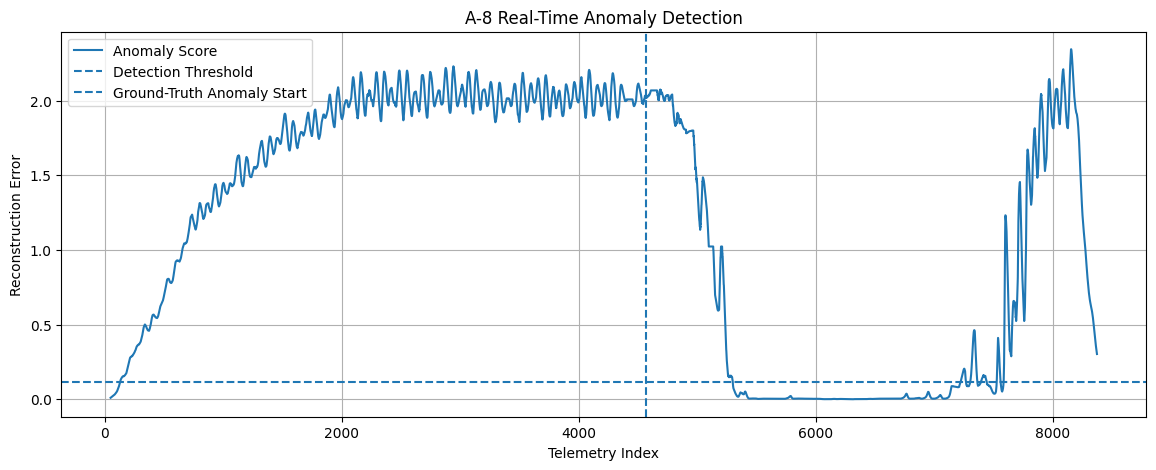

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    full_detections_df["telemetry_index"],
    full_detections_df["anomaly_score"],
    label="Anomaly Score"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Detection Threshold"
)

plt.axvline(
    4569,
    linestyle="--",
    label="Ground-Truth Anomaly Start"
)

plt.xlabel("Telemetry Index")
plt.ylabel("Reconstruction Error")
plt.title("A-8 Real-Time Anomaly Detection")

plt.legend()
plt.grid(True)
plt.show()

##Detection delay


In [30]:
anomaly_start = 4569

true_anomaly_detections = full_detections_df[
    (full_detections_df["telemetry_index"] >= anomaly_start)
    & (full_detections_df["prediction"] == 1)
]

if len(true_anomaly_detections) > 0:
    first_detection_index = (
        true_anomaly_detections["telemetry_index"].iloc[0]
    )

    detection_delay = (
        first_detection_index - anomaly_start
    )

    print("Ground-truth anomaly start:", anomaly_start)
    print("First detected anomaly:", first_detection_index)
    print("Detection delay:", detection_delay, "telemetry points")
else:
    print("No anomaly was detected after the ground-truth start.")

Ground-truth anomaly start: 4569
First detected anomaly: 4569
Detection delay: 0 telemetry points


##Save detection-delay result

In [31]:
delay_results = pd.DataFrame([{
    "channel": channel,
    "window_size": window_size,
    "threshold": threshold,
    "ground_truth_start": anomaly_start,
    "first_detection_index": first_detection_index,
    "detection_delay": detection_delay,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "false_positive_rate": fpr,
    "false_negative_rate": fnr
}])

delay_path = (
    project_path
    + "/results/realtime_detection_analysis_A8.csv"
)

delay_results.to_csv(
    delay_path,
    index=False
)

print("Real-time analysis saved.")
print(delay_path)

Real-time analysis saved.
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/realtime_detection_analysis_A8.csv


##Create a reusable detector function

Right now the pipeline works, but it is spread across several cells. We should turn it into a reusable function:

In [32]:
def realtime_detect(
    telemetry,
    model,
    threshold,
    window_size=50
):
    telemetry_buffer = []
    detections = []

    for index, value in enumerate(telemetry):

        telemetry_buffer.append(value)

        if len(telemetry_buffer) < window_size:
            continue

        window = np.array(
            telemetry_buffer[-window_size:],
            dtype=np.float32
        )

        window = torch.tensor(
            window
        ).unsqueeze(0).unsqueeze(-1)

        with torch.no_grad():
            reconstructed = model(window)

            error = torch.mean(
                (window - reconstructed) ** 2
            ).item()

        decision = (
            "ANOMALY"
            if error > threshold
            else "NORMAL"
        )

        detections.append({
            "telemetry_index": index,
            "anomaly_score": error,
            "decision": decision
        })

    return pd.DataFrame(detections)


print("Reusable real-time detector created.")

Reusable real-time detector created.


##Test the reusable detector

We'll run the new function on the same A-8 test telemetry and verify that it produces the same number of windows and decisions as our previous pipeline.

In [33]:
realtime_test_df = realtime_detect(
    test_telemetry,
    model,
    threshold,
    window_size
)

print("Windows evaluated:", len(realtime_test_df))

print("\nDecision counts:")
print(
    realtime_test_df["decision"].value_counts()
)

print("\nFirst 5 results:")
print(
    realtime_test_df.head()
)

Windows evaluated: 8326

Decision counts:
decision
ANOMALY    6144
NORMAL     2182
Name: count, dtype: int64

First 5 results:
   telemetry_index  anomaly_score decision
0               49       0.009550   NORMAL
1               50       0.010167   NORMAL
2               51       0.010782   NORMAL
3               52       0.011398   NORMAL
4               53       0.012014   NORMAL


##Verify the reusable detector

Now we'll compare the new detector with our previous full_detections_df.


In [34]:
same_scores = np.allclose(
    realtime_test_df["anomaly_score"].values,
    full_detections_df["anomaly_score"].values
)

same_decisions = (
    realtime_test_df["decision"].values
    == full_detections_df["decision"].values
).all()

print("Same anomaly scores:", same_scores)
print("Same decisions:", same_decisions)

Same anomaly scores: True
Same decisions: True


#Save the reusable detector results

In [35]:
realtime_test_path = (
    project_path
    + "/results/realtime_detector_verified_A8.csv"
)

realtime_test_df.to_csv(
    realtime_test_path,
    index=False
)

print("Verified real-time detector results saved.")
print("File:", realtime_test_path)
print("Rows:", len(realtime_test_df))

Verified real-time detector results saved.
File: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/realtime_detector_verified_A8.csv
Rows: 8326


##Create a simple real-time alert summary

Now let's summarize when the detector first raises an alert, how many alerts it produces, and the longest continuous alert period.

In [36]:
# Find anomaly detections
anomaly_detections = realtime_test_df[
    realtime_test_df["decision"] == "ANOMALY"
]

# First anomaly alert
first_alert_index = (
    anomaly_detections["telemetry_index"].iloc[0]
)

# Total anomaly alerts
total_alerts = len(anomaly_detections)

# Find longest continuous anomaly-alert streak
indices = anomaly_detections["telemetry_index"].values

longest_streak = 0
current_streak = 0
previous_index = None

for index in indices:

    if previous_index is not None and index == previous_index + 1:
        current_streak += 1
    else:
        current_streak = 1

    longest_streak = max(
        longest_streak,
        current_streak
    )

    previous_index = index

print("Real-Time Alert Summary")
print("-----------------------")
print("First anomaly alert:", first_alert_index)
print("Total anomaly alerts:", total_alerts)
print("Longest continuous alert streak:", longest_streak)

Real-Time Alert Summary
-----------------------
First anomaly alert: 130
Total anomaly alerts: 6144
Longest continuous alert streak: 5170


##Calculate alert rate

Now let's calculate the percentage of windows that produced anomaly alerts.

In [37]:
total_windows = len(realtime_test_df)

alert_rate = (
    total_alerts / total_windows
) * 100

print("Real-Time Alert Rate")
print("--------------------")
print("Total windows:", total_windows)
print("Anomaly alerts:", total_alerts)
print("Alert rate:", alert_rate, "%")

Real-Time Alert Rate
--------------------
Total windows: 8326
Anomaly alerts: 6144
Alert rate: 73.79293778525103 %


##Save the alert summary

Let's save these operational statistics so we can use them later in your paper.

In [38]:
alert_summary = pd.DataFrame([{
    "channel": channel,
    "total_windows": total_windows,
    "anomaly_alerts": total_alerts,
    "alert_rate_percent": alert_rate,
    "first_alert_index": first_alert_index,
    "longest_alert_streak": longest_streak
}])

alert_summary_path = (
    project_path
    + "/results/realtime_alert_summary_A8.csv"
)

alert_summary.to_csv(
    alert_summary_path,
    index=False
)

print("Alert summary saved.")
print("File:", alert_summary_path)

Alert summary saved.
File: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/realtime_alert_summary_A8.csv


##Create the final SERIAL 29 result summary

In [39]:
final_realtime_summary = pd.DataFrame([{
    "channel": channel,
    "model": "LSTM Autoencoder",
    "window_size": window_size,
    "threshold": threshold,
    "total_telemetry_points": len(test_telemetry),
    "windows_evaluated": len(realtime_test_df),
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "false_positive_rate": fpr,
    "false_negative_rate": fnr,
    "true_positives": tp,
    "false_positives": fp,
    "true_negatives": tn,
    "false_negatives": fn,
    "first_alert_index": first_alert_index,
    "detection_delay": detection_delay,
    "alert_rate_percent": alert_rate,
    "longest_alert_streak": longest_streak
}])

final_summary_path = (
    project_path
    + "/results/serial29_realtime_summary_A8.csv"
)

final_realtime_summary.to_csv(
    final_summary_path,
    index=False
)

print("SERIAL 29 final summary saved.")
print("File:", final_summary_path)
print("\nSummary:")
print(final_realtime_summary.T)

SERIAL 29 final summary saved.
File: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/serial29_realtime_summary_A8.csv

Summary:
                                       0
channel                              A-8
model                   LSTM Autoencoder
window_size                           50
threshold                       0.116136
total_telemetry_points              8375
windows_evaluated                   8326
precision                       0.277507
recall                          0.447977
f1_score                        0.342714
false_positive_rate              0.98208
false_negative_rate             0.552023
true_positives                      1705
false_positives                     4439
true_negatives                        81
false_negatives                     2101
first_alert_index                    130
detection_delay                        0
alert_rate_percent             73.792938
longest_alert_streak                5170


##github commit

In [40]:
import os

project_path = (
    "/content/drive/MyDrive/Spacecraft-Anomaly-Detection"
)

serial29_files = [
    "notebooks/29_realtime_detection_pipeline.ipynb",
    "results/realtime_detection_A8.csv",
    "results/realtime_detection_analysis_A8.csv",
    "results/realtime_detector_verified_A8.csv",
    "results/realtime_alert_summary_A8.csv",
    "results/serial29_realtime_summary_A8.csv"
]

print("SERIAL 29 files:")
for file in serial29_files:
    path = os.path.join(project_path, file)
    print(
        "✓" if os.path.exists(path) else "✗",
        file
    )

SERIAL 29 files:
✓ notebooks/29_realtime_detection_pipeline.ipynb
✓ results/realtime_detection_A8.csv
✓ results/realtime_detection_analysis_A8.csv
✓ results/realtime_detector_verified_A8.csv
✓ results/realtime_alert_summary_A8.csv
✓ results/serial29_realtime_summary_A8.csv


In [41]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git add notebooks/29_realtime_detection_pipeline.ipynb
!git add results/realtime_detection_A8.csv
!git add results/realtime_detection_analysis_A8.csv
!git add results/realtime_detector_verified_A8.csv
!git add results/realtime_alert_summary_A8.csv
!git add results/serial29_realtime_summary_A8.csv

print("SERIAL 29 files staged.")
!git status --short

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
SERIAL 29 files staged.
Refresh index: 100% (61/61), done.
 M notebooks/13_evaluate_global_zscore.ipynb
 M notebooks/14_rolling_zscore.ipynb
 M notebooks/15_compare_statistical_methods.ipynb
 M notebooks/16_isolation_forest.ipynb
 M notebooks/17_evaluate_isolation_forest.ipynb
 M notebooks/18_one_class_svm.ipynb
 M notebooks/19_compare_classical_methods.ipynb
 M notebooks/20_autoencoder.ipynb
 M notebooks/21_analyze_autoencoder.ipynb
 M notebooks/22_time_series_windows.ipynb
 M notebooks/23_lstm_autoencoder.ipynb
 M notebooks/24_evaluate_lstm_autoencoder.ipynb
 M notebooks/25_model_comparison_and_research_gap.ipynb
 M notebooks/26_explainable_ai.ipynb
 M notebooks/27_computational_cost_analysis.ipynb
 M notebooks/28_lightweight_optimization.ipynb
A  notebooks/29_realtime_detection_pipeline.ipynb
A  results/realtime_alert_summary_A8.csv
A  results/realtime_detection_A8.csv
A  results/realtime_detection_analysis_A8.csv
A  results/realti

In [42]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git commit -m "Complete SERIAL 29 real-time detection pipeline"

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@ff8d56918f10.(none)')


In [43]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

print("Git identity configured.")
!git config --global user.name
!git config --global user.email

Git identity configured.
Amit Chandra Das
arickroy0@gmail.com


In [44]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git commit -m "Complete SERIAL 29 real-time detection pipeline"

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
[main 9bb5a55] Complete SERIAL 29 real-time detection pipeline
 6 files changed, 16661 insertions(+)
 create mode 100644 notebooks/29_realtime_detection_pipeline.ipynb
 create mode 100644 results/realtime_alert_summary_A8.csv
 create mode 100644 results/realtime_detection_A8.csv
 create mode 100644 results/realtime_detection_analysis_A8.csv
 create mode 100644 results/realtime_detector_verified_A8.csv
 create mode 100644 results/serial29_realtime_summary_A8.csv


In [45]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git push origin main

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (10/10), 211.03 KiB | 2.13 MiB/s, done.
Total 10 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   8c6819d..9bb5a55  main -> main
